In [47]:
import os
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
import datetime as dt
import yfinance as yf

warnings.filterwarnings('ignore')
rcParams['figure.figsize'] = 15, 6

# Chọn mã cổ phiếu phù hợp với tên notebook
bank_stock_name = "ACB.VN"

model_dir = os.path.join(os.getcwd(), '..', 'Save_model_XGBoost')
stock_model_dir = os.path.join(model_dir, bank_stock_name)
print('Model dir:', stock_model_dir)
if not os.path.exists(stock_model_dir):
    os.makedirs(stock_model_dir, exist_ok=True)

Model dir: c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_XGBoost\..\Save_model_XGBoost\ACB.VN


In [48]:
def save_model(stock_model_dir, model_name, model):
    model_name = model_name + ".pkl"
    model_path = os.path.join(stock_model_dir, model_name)
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved model to {model_path}")

def load_model(stock_model_dir, model_name):
    model_name = model_name + ".pkl"
    model_path = os.path.join(stock_model_dir, model_name)
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    print(f"Loaded model from {model_path}")
    return model

def update_model_loss(stock_model_dir, model_name, rmse, mae, r2):
    model_loss_log = os.path.join(stock_model_dir, "model_loss.json")
    loss_detail = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }
    try:
        with open(model_loss_log, 'r') as f:
            model_loss = json.load(f)
    except:
        model_loss = {}
    model_loss[model_name] = loss_detail

    with open(model_loss_log, 'w') as f:
        json.dump(model_loss, f, indent=4, ensure_ascii=False)

In [49]:
stock = pd.read_csv(f'../data/{bank_stock_name}.csv')
stock.head()

,Price,Date,Close,High,Low,Open,Volume
0,0,2020-11-26,10515.915039,10631.052834,10362.397979,10477.535774,25156125
1,1,2020-11-27,10439.156250,10592.673306,10439.156250,10554.294042,15970407
2,2,2020-11-30,10439.156250,10515.914778,10362.397722,10515.914778,21254075
3,3,2020-12-01,10477.536133,10477.536133,10285.639801,10439.156867,22004479
4,4,2020-12-09,10957.276367,11110.793430,10669.431429,10784.569226,57510292


In [50]:
# Import XGBoost
from xgboost import XGBRegressor

print("XGBoost imported successfully")

XGBoost imported successfully


In [51]:
# Chuẩn bị dữ liệu
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')
stock.set_index('Date', inplace=True)

# Sử dụng cột Close để dự đoán
close_data = stock[['Close']].copy()
print(f"Data shape: {close_data.shape}")
print(f"Date range: {close_data.index.min()} to {close_data.index.max()}")
close_data.head()

Data shape: (1242, 1)
Date range: 2020-11-26 00:00:00 to 2025-11-25 00:00:00


,Close
Date,
2020-11-26,10515.915039
2020-11-27,10439.156250
2020-11-30,10439.156250
2020-12-01,10477.536133
2020-12-09,10957.276367


In [52]:
# Tạo features từ dữ liệu time series
def create_features(df, target_col='Close', lag_days=5):
    """
    Tạo các features cho mô hình XGBoost từ time series data
    """
    df_features = df.copy()
    
    # Tạo lag features (giá trị quá khứ)
    for i in range(1, lag_days + 1):
        df_features[f'lag_{i}'] = df_features[target_col].shift(i)
    
    # Tạo rolling statistics
    for window in [3, 5, 7, 14]:
        df_features[f'rolling_mean_{window}'] = df_features[target_col].shift(1).rolling(window=window).mean()
        df_features[f'rolling_std_{window}'] = df_features[target_col].shift(1).rolling(window=window).std()
    
    # Tạo date features
    df_features['day_of_week'] = df_features.index.dayofweek
    df_features['day_of_month'] = df_features.index.day
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    
    # Xóa các hàng có NaN
    df_features = df_features.dropna()
    
    return df_features

# Tạo features
df_with_features = create_features(close_data, lag_days=7)
print(f"Shape after creating features: {df_with_features.shape}")
df_with_features.head()

Shape after creating features: (1228, 20)


,Close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_3,rolling_std_3,rolling_mean_5,rolling_std_5,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,day_of_week,day_of_month,month,quarter
Date,,,,,,,,,,,,,,,,,,,,
2020-12-23,10784.569336,11034.034180,11110.793945,10899.707031,10861.327148,10842.137695,10746.189453,10822.948242,11014.845052,106.843756,10949.600000,117.198731,10902.448242,127.014219,10764.008998,219.759545,2,23,12,4
2020-12-24,10477.536133,10784.569336,11034.034180,11110.793945,10899.707031,10861.327148,10842.137695,10746.189453,10976.465820,170.561458,10938.086328,132.255737,10896.965541,131.757629,10783.198591,207.835382,3,24,12,4
2020-12-25,10727.000000,10477.536133,10784.569336,11034.034180,11110.793945,10899.707031,10861.327148,10842.137695,10765.379883,278.744857,10861.328125,248.355452,10858.586496,202.911056,10785.940011,203.148541,4,25,12,4
2020-12-28,10669.431641,10727.000000,10477.536133,10784.569336,11034.034180,11110.793945,10899.707031,10861.327148,10663.035156,163.205309,10826.786719,253.637183,10842.138253,209.040670,10806.500279,178.411385,0,28,12,4
2020-12-29,10631.052734,10669.431641,10727.000000,10477.536133,10784.569336,11034.034180,11110.793945,10899.707031,10624.655924,130.620457,10738.514258,201.536388,10814.724609,218.474565,10820.207101,157.318446,1,29,12,4


In [53]:
# Chia dữ liệu train/test (80/20)
train_size = int(len(df_with_features) * 0.8)
train_data = df_with_features[:train_size]
test_data = df_with_features[train_size:]

# Tách X và y
X_train = train_data.drop('Close', axis=1)
y_train = train_data['Close']
X_test = test_data.drop('Close', axis=1)
y_test = test_data['Close']

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f"Features: {X_train.columns.tolist()}")

Train size: 982
Test size: 246
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'day_of_week', 'day_of_month', 'month', 'quarter']


In [54]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed")

Data scaling completed


In [55]:
# Xây dựng mô hình XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost model...")
xgb_model.fit(X_train_scaled, y_train, 
              eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
              verbose=False)

print("Model training completed!")

Training XGBoost model...
Model training completed!


In [56]:
# Dự đoán
train_predictions = xgb_model.predict(X_train_scaled)
test_predictions = xgb_model.predict(X_test_scaled)

# Tính toán metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
train_mae = mean_absolute_error(y_train, train_predictions)
train_r2 = r2_score(y_train, train_predictions)

test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("="*50)
print("TRAIN METRICS:")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R2 Score: {train_r2:.4f}")
print("="*50)
print("TEST METRICS:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R2 Score: {test_r2:.4f}")
print("="*50)

TRAIN METRICS:
RMSE: 110.9848
MAE: 84.6177
R2 Score: 0.9981
TEST METRICS:
RMSE: 2679.4729
MAE: 1740.7011
R2 Score: -0.2983


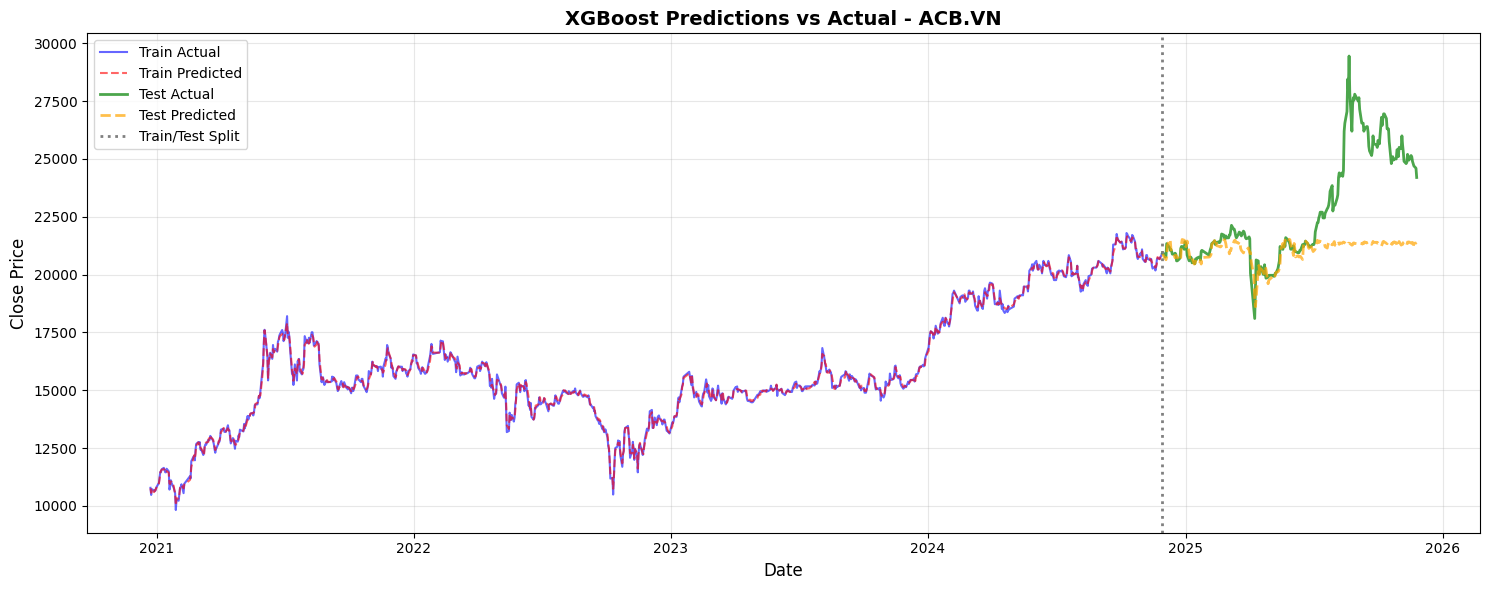

In [57]:
# Visualize predictions vs actual
plt.figure(figsize=(15, 6))

# Plot all data on one chart
plt.plot(train_data.index, y_train.values, label='Train Actual', color='blue', alpha=0.6, linewidth=1.5)
plt.plot(train_data.index, train_predictions, label='Train Predicted', color='red', alpha=0.6, linewidth=1.5, linestyle='--')
plt.plot(test_data.index, y_test.values, label='Test Actual', color='green', alpha=0.7, linewidth=2)
plt.plot(test_data.index, test_predictions, label='Test Predicted', color='orange', alpha=0.7, linewidth=2, linestyle='--')

# Add vertical line to separate train and test
plt.axvline(x=train_data.index[-1], color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

plt.title(f'XGBoost Predictions vs Actual - {bank_stock_name}', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

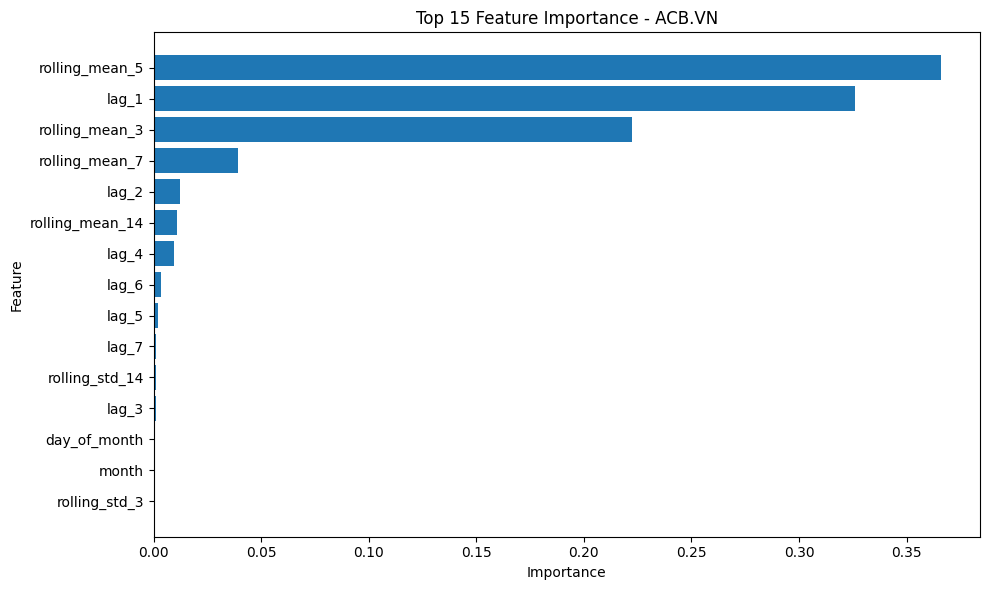


Top 10 Important Features:
            feature  importance
9    rolling_mean_5    0.365860
0             lag_1    0.326102
7    rolling_mean_3    0.222244
11   rolling_mean_7    0.039361
1             lag_2    0.012083
13  rolling_mean_14    0.010685
3             lag_4    0.009542
5             lag_6    0.003435
4             lag_5    0.002179
6             lag_7    0.001265


In [58]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top 15 Feature Importance - {bank_stock_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

In [59]:
# Lưu model và kết quả
# Lưu model
save_model(stock_model_dir, "XGBoost", xgb_model)

# Lưu scaler
save_model(stock_model_dir, "XGBoost_scaler", scaler)

# Lưu metrics
update_model_loss(stock_model_dir, "XGBoost", test_rmse, test_mae, test_r2)

print("Model and results saved successfully!")

Saved model to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_XGBoost\..\Save_model_XGBoost\ACB.VN\XGBoost.pkl
Saved model to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_XGBoost\..\Save_model_XGBoost\ACB.VN\XGBoost_scaler.pkl
Model and results saved successfully!


In [60]:
# Lưu predictions vào CSV
predictions_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': y_test.values,
    'Predicted': test_predictions
})
predictions_df['Error'] = predictions_df['Actual'] - predictions_df['Predicted']
predictions_df['Error_Percent'] = (predictions_df['Error'] / predictions_df['Actual']) * 100

predictions_path = os.path.join(stock_model_dir, 'xgboost_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to {predictions_path}")

predictions_df.head(10)

Predictions saved to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_XGBoost\..\Save_model_XGBoost\ACB.VN\xgboost_predictions.csv


,Date,Actual,Predicted,Error,Error_Percent
0,2024-11-29,20926.742188,20898.542969,28.199219,0.134752
1,2024-12-02,20885.220703,20738.500000,146.720703,0.702510
2,2024-12-03,20760.656250,20701.220703,59.435547,0.286289
3,2024-12-04,20802.177734,20642.824219,159.353516,0.766042
4,2024-12-05,21341.955078,20763.833984,578.121094,2.708848
5,2024-12-06,21300.433594,21266.339844,34.093750,0.160061
6,2024-12-09,21175.869141,21473.152344,-297.283203,-1.403877
7,2024-12-10,21051.306641,21519.718750,-468.412109,-2.225098
8,2024-12-11,21092.828125,21122.531250,-29.703125,-0.140821
9,2024-12-12,21009.785156,20984.158203,25.626953,0.121976


In [61]:
# Lưu thông tin về features và parameters
xgb_info = {
    'model_type': 'XGBoost',
    'bank_stock': bank_stock_name,
    'train_size': len(train_data),
    'test_size': len(test_data),
    'features': X_train.columns.tolist(),
    'n_features': len(X_train.columns),
    'parameters': {
        'n_estimators': xgb_model.n_estimators,
        'learning_rate': xgb_model.learning_rate,
        'max_depth': xgb_model.max_depth,
        'min_child_weight': xgb_model.min_child_weight,
        'subsample': xgb_model.subsample,
        'colsample_bytree': xgb_model.colsample_bytree,
        'gamma': xgb_model.gamma
    },
    'train_metrics': {
        'rmse': float(train_rmse),
        'mae': float(train_mae),
        'r2': float(train_r2)
    },
    'test_metrics': {
        'rmse': float(test_rmse),
        'mae': float(test_mae),
        'r2': float(test_r2)
    }
}

xgb_params_path = os.path.join(stock_model_dir, 'xgboost_params.json')
with open(xgb_params_path, 'w') as f:
    json.dump(xgb_info, f, indent=4)

print(f"Model information saved to {xgb_params_path}")
print("\nModel Summary:")
print(json.dumps(xgb_info, indent=2))

Model information saved to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_XGBoost\..\Save_model_XGBoost\ACB.VN\xgboost_params.json

Model Summary:
{
  "model_type": "XGBoost",
  "bank_stock": "ACB.VN",
  "train_size": 982,
  "test_size": 246,
  "features": [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "lag_6",
    "lag_7",
    "rolling_mean_3",
    "rolling_std_3",
    "rolling_mean_5",
    "rolling_std_5",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "rolling_std_14",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter"
  ],
  "n_features": 19,
  "parameters": {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 5,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0
  },
  "train_metrics": {
    "rmse": 110.9847981017913,
    "mae": 84.61770263174644,
    "r2": 0.9980671873955576
  },
  "test_metrics": {
    "rmse": 2679.472924346666,
    "mae": 1740.701124237804